In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import naive_bayes
import sklearn.metrics as metrics

In [2]:
df = pd.read_excel(fr"processed_heart_data.xlsx")

In [3]:
# print(df.shape)

In [4]:
x = df.drop('disease_present', axis = 1) # features
y = df['disease_present']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = .2, random_state=42)

## Model Creation   
Since the dataset is not too large, I will be creating a models for several of the naive bayes algorithms

In [7]:
model_list = [] # creating a list to make it easier to code later

gaussian_model = naive_bayes.GaussianNB()
# the data is not normally distributed but I will try this model anyways
model_list.append(gaussian_model)

multinomial_model = naive_bayes.MultinomialNB()
# this model is best for discrete values, so a expect potential issues with the model due to the continous and categorical values in the dataset
model_list.append(multinomial_model)


complement_model = naive_bayes.ComplementNB()
# based off of multinomial so it inherits the potential issue, but also better for imbalanced datasets which, even after cleaning, this dataset is imbalanced
model_list.append(complement_model)

'''
# I will not be using the Bernoulli because it binarizes any non-binary features which will require
additioanl parameter tuning outside the current scope of the project.
# Similarly, I will not be using the Categorical model because it assumes all values are categorical
# I will also exclude Out-of-core model because the dataset is too small for it to be useful
'''

print(model_list)

[GaussianNB(), MultinomialNB(), ComplementNB()]


### Build Models

In [9]:

models_dict = {
    "gauss_model": 0,
    "multinomial_model": 0,
    "complement_model": 0,
}

model_index = 0
for x in models_dict:
    try:
        models_dict[x] = model_list[model_index].fit(x_train,y_train)
    except Exception as e:
        print(f"An error occurred: {e}")
        print(f"error with {x}")
    model_index += 1

### Get y_predictions

In [11]:
models_y_pred_dict = {
    "gauss_model": 0,
    "multinomial_model": 0,
    "complement_model": 0,
}

for x in models_y_pred_dict:
    models_y_pred_dict[x] = models_dict[x].predict(x_test)

### Models Results

In [26]:
for x in models_y_pred_dict:
    curr_pred = models_y_pred_dict[x] 
    print(x)
    print(f"\tAccuracy Score: {metrics.accuracy_score(y_test, curr_pred)}")
    print(f"\tPrecision Score: {metrics.precision_score(y_test, curr_pred)}")
    print(f"\tRecall Score: {metrics.recall_score(y_test, curr_pred)}")
    print(f"\tF1 Score: {metrics.f1_score(y_test, curr_pred)}")

gauss_model
	Accuracy Score: 0.8852459016393442
	Precision Score: 0.9032258064516129
	Recall Score: 0.875
	F1 Score: 0.8888888888888888
multinomial_model
	Accuracy Score: 0.8524590163934426
	Precision Score: 0.896551724137931
	Recall Score: 0.8125
	F1 Score: 0.8524590163934426
complement_model
	Accuracy Score: 0.8524590163934426
	Precision Score: 0.896551724137931
	Recall Score: 0.8125
	F1 Score: 0.8524590163934426


The gauss model appears to be scoreing the highest on all metrics

In [31]:
models_cm_dict = {
    "gauss_model": 0,
    "multinomial_model": 0,
    "complement_model": 0,
}

for x in models_cm_dict:
    models_cm_dict[x] = metrics.confusion_matrix(y_test, models_y_pred_dict[x])

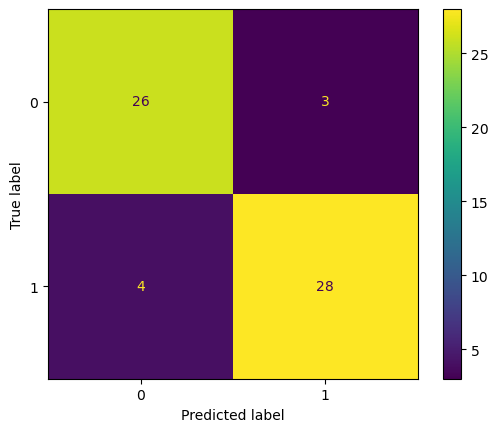

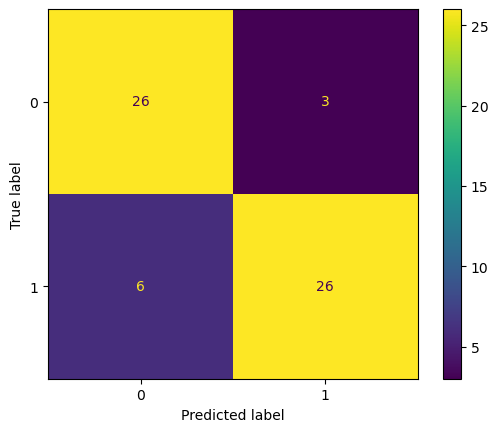

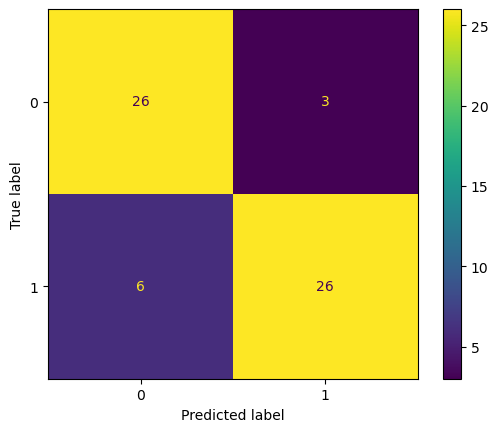

In [41]:
for x in models_cm_dict:
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix = models_cm_dict[x])
    disp.plot()

- The upper-left quadrant displays the number of true negatives.
- The bottom-left quadrant displays the number of false negatives.
- The upper-right quadrant displays the number of false positives.
- The bottom-right quadrant displays the number of true positives.